# 07 · PFM image → two domains → DC bias dependence

Chains the pieces that already exist into the run Liam asked for:

1. optical check and an explicit laser re-sync (**required** — position is tracked in
   software and the last kernel died with the spot near the base),
2. a 20 µm single-frequency PFM image at the contact resonance,
3. automatic domain segmentation → two candidate spots → **you confirm** → spots written
   into `root:Packages:MFP3D:Force:SpotX/Y`,
4. a spot shakedown that refuses to continue if the coordinate convention is wrong,
5. the notebook-04/05 series: every bias at both domains at each laser position.

The physics of the separation is unchanged from notebook 05:

```
    Z_up   = +P + E              P = (Z_up − Z_down)/2   → piezo        → D-NS
    Z_down = −P + E              E = (Z_up + Z_down)/2   → electrostatic → D-ESBS
```

With ≥3 biases the complex fit `Z = a + bV` per (x, f) also separates the channels
independently, and the two answers disagreeing is the warning that a contact-gain
difference between the spots is leaking piezo into the electrostatic channel.
---
**2026-09-18 design (supersedes the AL loop below in §7).** Not a dense map vs bias. Three fixed
designs, run in this order (the load series first — §4b, single domain, no imaging needed):

0. **Load series** — 50 / 150 / 300 / 450 nN true, 0 V, one domain, 8 sparse positions (~30 min).

1. **Sparse survey** — 8 equispaced laser positions over 75–445 µm, both domains × 9 biases
   (18 tunes/position, ~5 min). Gives the electrostatic/piezo ratio per mode, V_cpd, and the
   wideband reconstruction test (low-rank rank ≈ N/2 recovers 5–995 kHz from ≥ 8 positions).
2. **Free-end cluster** — 420–445 µm at 2 µm pitch, one domain × 5 biases. On resonance the
   CR1 null (12.6 µm from the tip at 0 V) is a mode-shape node and must NOT move with bias
   (that is the check on the axis and the contact). **Off resonance** (±1–6 kHz) the null is
   the crossing of two drive pathways and moves by several to tens of µm with V_dc if the
   electrostatic drive is ~4× the contact drive; with contact drive alone it barely moves.

Between them a **go/no-go after position 1**: CR1 should swing hard with bias and CR3–CR5
barely; CR3–CR5 should flip ~180° between domains and CR1 much less. If CR3 behaves like CR1
the mixture picture is wrong — stop and look before spending the remaining hours.
Keep the full 5–995 kHz × 32000-point tune throughout; the higher modes are the piezo-clean channel.


## 1 · Imports

In [7]:
import sys, os, time
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
import matplotlib.pyplot as plt
import win32com.client

from activemodemap.asylum import AFMLaserSweepAutomation, AsylumInstrument
from activemodemap.domains import (load_asylum_image, list_channels, find_domain_spots,
                                   read_spots_from_igor, write_spots_to_igor,
                                   verify_spot_moves, plot_domain_confirmation)
from activemodemap import (make_conditions, run_series, separate_domains,
                           separate_channels, channel_spots, estimate_v_cpd,
                           load_checkpoint)

igor = win32com.client.Dispatch('IgorPro.Application')
print('Connected to Igor Pro')

Connected to Igor Pro


## 2 · Parameters

In [8]:
file_loc      = r'D:\User Data\Liam\ActiveModeMap\DomainsBPPPCONTAU'
base_filename = 'DomBias'
os.makedirs(file_loc, exist_ok=True)

# --- probe geometry (x = 0 is the clamped BASE) ------------------------------
# Reach from the 2026-09-17 dense sweep: InvOLS ran away below x = 75 um, so the
# usable span on this 445 um lever at 100 nN is x = 75 .. 445.
PROBE_L_UM = 445.0
START_AT   = 'free_end'
X_LO_UM    = 75.0
step_um    = 5.0
x_grid     = np.arange(X_LO_UM, PROBE_L_UM + 1e-6, step_um)
HW_SIGN_TOWARD_FREE_END = +1          # DoLDMove(+x) goes toward the tip on this Cypher

# --- probe recalibration 2026-09-18 (thermal): k = 148.18 pN/nm, f0 = 13.393 kHz, Q = 42 ------
# Yesterday's panel k was 0.4057 N/m, so the "100 nN" dense sweep was really
# 100 * 0.148/0.4057 = 36.5 nN (deflection 247 nm, setpoint 0.483 V at the tip InvOLS).
# To reproduce yesterday's contact (and CR1 = 63.47 kHz) the load must be given in TRUE
# newtons with the new k: 36.5 nN. Setting 100 nN would apply 2.7x yesterday's force and
# move CR1 by several kHz. Flip LOAD_NN to [100.0] only if a genuinely higher load is wanted.
K_LEVER_N_PER_M = 0.14818
F0_FREE_HZ      = 13.393e3
LOAD_TRUE_NN    = 100.0 * K_LEVER_N_PER_M / 0.4057          # 36.5 nN = yesterday's actual load
LOAD_TRUE_NN    = 100 * K_LEVER_N_PER_M 

# --- imaging -----------------------------------------------------------------
SCAN_SIZE_M   = 6e-6
SCAN_POINTS   = 256
SCAN_RATE_HZ  = 1.0
IMAGE_LOAD_NN = LOAD_TRUE_NN            # same deflection as the dense sweep
CR_GUESS_HZ   = 63.47e3               # contact mode 1, measured 2026-09-17 at 100 nN
PFM_DRIVE_V   = 1.0                   # AC drive amplitude for imaging

# --- the bias series ---------------------------------------------------------
BIAS_V  = [-9, -6 ,-3, 0 ,3, 6 , 9]
BIAS_ORDER = 'interleaved'            # 0, +4, -4, +3, -3, ... : drift becomes scatter, not slope
LOAD_NN = [LOAD_TRUE_NN]               # true newtons with the recalibrated k
SPOT_UP, SPOT_DOWN = 1, 2             # which is physically 'up' only sets the sign of P
REF_INDEX = 0

# --- reconstruction ----------------------------------------------------------
DNS_BAND_HZ   = (55e3, 72e3)          # brackets contact mode 1 and its antiresonance
RANK          = 4
MIN_POSITIONS = 6
MAX_POSITIONS = 14
DNS_CI_TOL_UM = 1.0
CHECKPOINT = os.path.join(file_loc, 'domains_bias_checkpoint.npz')

# --- the 2026-09-18 design: sparse survey + free-end cluster --------------------
SPARSE_X_UM    = np.round(np.linspace(X_LO_UM, PROBE_L_UM, 8), 1)   # 75 ... 445, 8 positions
CLUSTER_X_UM   = np.arange(420.0, PROBE_L_UM + 1e-6, 2.0)            # CR1 null region, 2 um pitch
CLUSTER_BIAS_V = [-9,-6, -3, 0, 3, 6, 9]
CLUSTER_SPOTS  = [SPOT_UP]                                            # add SPOT_DOWN if time allows (+25 min)
CLUSTER_CHECKPOINT = os.path.join(file_loc, 'cluster_bias_checkpoint.npz')

# --- 4b: single-domain load series, run FIRST (Liam, 2026-09-18) ----------------
# True newtons with the recalibrated k. Deflection = F/k: 0.34 / 1.0 / 2.0 / 3.0 um;
# setpoint at the tip (InvOLS 5.1e-7): 0.66 / 2.0 / 4.0 / 6.0 V; at x = 75 (9.1e-6): 0.04-0.33 V.
# Ascending, so tip wear from 450 nN comes last. Loads are re-engaged per condition.
LOADS_NN        = [25, 50, 100, 200.0]
LOAD_X_UM       = None                     # None -> SPARSE_X_UM (8 positions, 445 -> 75)
LOAD_CHECKPOINT = os.path.join(file_loc, 'load_series_checkpoint.npz')
LOAD_DNS_BAND_HZ = (55e3, 85e3)            # CR1 stiffens with load: 63.5 kHz -> toward the ~75 kHz pinned limit

# --- what the tune must look like (checked after the first tune) -----------------
TUNE_MIN_SPAN_HZ = 900e3      # 5-995 kHz window
TUNE_MIN_POINTS  = 30000      # 32000-point tune, ~10.5 s
MODES_KHZ = [63.47, 200.12, 408.02, 667.34, 916.14]   # CR1-CR5 from the dense sweep
MODE_HALF_WIN_HZ = 4e3

T_TUNE_S = 10.5 + 2.0        # 32000-pt tune + bias settle
n_cond = len(BIAS_V) * len(LOAD_NN) * 2
t_sparse  = len(SPARSE_X_UM) * (n_cond * T_TUNE_S + 60 + 2 * 30) / 60       # + setup + 2 spot hops
t_cluster = len(CLUSTER_X_UM) * (len(CLUSTER_BIAS_V) * len(CLUSTER_SPOTS) * T_TUNE_S + 60) / 60
t_load = len(SPARSE_X_UM) * (len(LOADS_NN) * (T_TUNE_S + 20.0) + 60) / 60                # re-engage per load
print(f'load series  : {len(SPARSE_X_UM)} positions x {len(LOADS_NN)} loads       ~{t_load:.0f} min  (first)')
print(f'sparse survey : {len(SPARSE_X_UM)} positions x {n_cond} conditions  ~{t_sparse:.0f} min')
print(f'free-end cluster: {len(CLUSTER_X_UM)} positions x {len(CLUSTER_BIAS_V) * len(CLUSTER_SPOTS)} conditions  ~{t_cluster:.0f} min')
print(f'total ~{(t_load + t_sparse + t_cluster) / 60:.1f} h (plus image + domain finding ~30 min)')

load series  : 8 positions x 4 loads       ~25 min  (first)
sparse survey : 8 positions x 14 conditions  ~39 min
free-end cluster: 13 positions x 7 conditions  ~32 min
total ~1.6 h (plus image + domain finding ~30 min)


## 3 · Optical check and laser re-sync — do not skip

The laser position is tracked **only** in software, by summing relative `DoLDMove`
calls. The kernel that ran the dense sweep is gone, so nothing in Python knows where
the spot is. It was left at **x ≈ 5 µm, near the clamped base**.

Look at the optical view, decide where the spot actually is, put that number in
`X_ACTUAL_UM`, and run the cell. `set_position(confirm=True)` changes bookkeeping only
— it moves nothing — and then one tracked move parks the laser at the free end.

In [9]:
automation = AFMLaserSweepAutomation(igor, file_loc, base_filename,
                                     log_filename=os.path.join(file_loc, 'DomBias_log'))
automation.eigenmode_center_freq = CR_GUESS_HZ
automation.resonance_band_Hz     = DNS_BAND_HZ
automation.autowedge_pause       = 15.0
automation.wait_for_tune_complete = True
automation.tune_timeout_s        = 600.0     # 32000-point tunes take ~10.5 s
automation.verbose_tune          = True
automation.spot_timeout_s        = 90.0
automation.spot_stable_tol_V     = 2e-3
automation.set_folder()

inst = AsylumInstrument(automation, load_nN=LOAD_NN[0], dc_bias_V=0.0,
                        recalibrate_each=True, analysis_band_Hz=None,
                        start_at=START_AT, span_um=PROBE_L_UM,
                        x_limits_um=(x_grid[0], x_grid[-1]),
                        hw_sign_toward_free_end=HW_SIGN_TOWARD_FREE_END,
                        apply_bias=False)

X_ACTUAL_UM = 445.0        # <-- WHERE THE SPOT REALLY IS, from the optical view
inst.set_position(X_ACTUAL_UM, confirm=True)
print('bookkeeping now says x =', inst.current_x)

inst.preview_moves([PROBE_L_UM])          # should read 'toward free end'

  tracked position re-synced: 445.0 -> 445.0 um (no motion commanded)
bookkeeping now says x = 445.0
start: x = 445.0 um (free end, 0.0 um from the free end)
  x = 0 is the clamped base; hw_sign_toward_free_end = +1
  x =   445.0 um   DoLDMove(    +0.0, 0)   no move


In [10]:
# Park at the free end (one tracked, limit-checked move + an optical capture).
automation.withdraw(); time.sleep(1)
inst.move_to(PROBE_L_UM, capture_image=True)
print('laser parked at x =', inst.current_x)

  laser moved to x = 445.0 um (0.0 um from the free end)  [DoLDMove(+0.0)]
  optical image captured — check the spot is on the cantilever before continuing
laser parked at x = 445.0


## 4 · 20 µm PFM image at the contact resonance

Engages at `IMAGE_LOAD_NN`, tunes to find the contact resonance, sets the drive there
and takes one image. Check the phase channel has real contrast before going on — the
segmentation in §5 refuses a single-domain field of view, but it cannot tell you that
the *sample* is in the wrong place.

In [11]:
inst.a.do_autowedge()
invols = inst.a.measure_invols(); inst._invols = invols
inst._spring = inst.a.get_gmv()['SpringConstant']
setpoint_V = inst.set_load(IMAGE_LOAD_NN, reengage=True)
print(f'engaged at {IMAGE_LOAD_NN:.0f} nN (setpoint {setpoint_V:.4f} V)')

tune = inst.a.tune_eigenmode(position_label='PFMIMG', scan_index=0)
f_cr = tune['resonance_freq']
print(f'contact resonance {f_cr/1e3:.2f} kHz, Q {tune["q_factor"]:.0f}')

igor.Execute(f'PV("ScanSize", {SCAN_SIZE_M})')
igor.Execute(f'PV("ScanPoints", {SCAN_POINTS})')
igor.Execute(f'PV("ScanLines", {SCAN_POINTS})')
igor.Execute(f'PV("ScanRate", {SCAN_RATE_HZ})')
igor.Execute(f'PV("DriveFrequency", {f_cr})')
igor.Execute(f'PV("DriveAmplitude", {PFM_DRIVE_V})')
time.sleep(1)

engaged at 15 nN (setpoint 0.2022 V)
      tune finished after 10.4 s
contact resonance 64.29 kHz, Q 102


In [12]:
# --- checks on the first tune: window, phase convention, higher modes -----------
from activemodemap.asylum import check_phase_convention, tune_to_complex

td = tune['tune_data']
f_td = np.asarray(td['frequency'], float); good = np.isfinite(f_td) & np.isfinite(td['amplitude'])
span = f_td[good].max() - f_td[good].min(); npts = int(good.sum())
print(f'tune window {f_td[good].min()/1e3:.1f}-{f_td[good].max()/1e3:.1f} kHz, {npts} finite points')
assert span >= TUNE_MIN_SPAN_HZ and npts >= TUNE_MIN_POINTS, \
    'set the Tune panel to 5-995 kHz x 32000 points (it was yesterday); the higher modes are needed'
# f0 moved 13.649 -> 13.393 kHz (-1.9 %) between yesterday's tune and today's thermal fit; if that
# is a real change of the lever CR1 follows it (~ -1.2 kHz). Tolerate 1.5 kHz, but PRINT the shift.
print(f'CR1 {f_cr/1e3:.2f} kHz vs 63.47 yesterday ({(f_cr - CR_GUESS_HZ):+.0f} Hz); panel k {inst._spring:.4f} N/m '
      f'(expect {K_LEVER_N_PER_M}); InvOLS {invols:.3e} m/V; setpoint {setpoint_V:.3f} V for {LOAD_NN[0]:.1f} nN')
assert abs(f_cr - CR_GUESS_HZ) < 1500, f'CR1 at {f_cr/1e3:.2f} kHz, expected ~63.5 - load recipe or contact changed?'
assert abs(inst._spring - K_LEVER_N_PER_M) / K_LEVER_N_PER_M < 0.05, 'panel spring constant is not the recalibrated 0.148 N/m'

# the Cypher phase must RISE through the peak (+158 deg yesterday); PHASE_SIGN=-1 conjugates it.
dphi = check_phase_convention(td, expect_sign=+1.0)
assert np.isfinite(dphi) and dphi > 45, f'raw phase slope {dphi:+.0f} deg - convention differs from yesterday, stop'
f_z, Z1 = tune_to_complex(td, check_convention=False)
A1 = np.abs(Z1); floor = np.median(A1[f_z > 950e3])
print('mode   f_peak   peak/floor (dB)')
for fk in MODES_KHZ:
    w = np.abs(f_z - fk * 1e3) <= MODE_HALF_WIN_HZ
    j = np.argmax(A1[w]); print(f'{fk:7.1f}  {f_z[w][j]/1e3:7.2f}  {20*np.log10(A1[w][j]/floor):5.1f}')
# CR1 sits at the tip end here; CR3+ should still be >= 15 dB above the floor at x = 445


tune window 0.1-1100.1 kHz, 47040 finite points
CR1 64.29 kHz vs 63.47 yesterday (+822 Hz); panel k 0.1482 N/m (expect 0.14818); InvOLS 4.945e-07 m/V; setpoint 0.202 V for 14.8 nN
mode   f_peak   peak/floor (dB)
   63.5    64.29   13.8
  200.1   200.48   11.3
  408.0   411.41   -2.0
  667.3   670.83    4.1
  916.1   914.62    4.1


## 4b · Single-domain load series — run this FIRST

One domain (the spot the tip is on now), 0 V, loads 50 / 150 / 300 / 450 nN **true** with the
recalibrated k, at the 8 sparse positions, free end first. ~4 conditions × (re-engage ~20 s +
tune 10.5 s) + 1 min setup ≈ 3.5 min per position, **~30 min** total.

What it gives: CR1–CR5 frequency vs load (Hertz: k₁ ∝ F^1/3, CR1 climbs toward the ~75 kHz
clamped–pinned limit), the D-NS migration with load (the manuscript's load-sweep observable),
mode-shape changes at the free end, and a check that 450 nN on a 3 µm-deflected lever is
still linear (deflection setpoint 6 V at the tip — watch the photodiode range).

Watch: setpoint at x = 75 for 50 nN is only ~0.04 V — that condition may fail there and is
recorded as None, not an abort. Tip wear at 450 nN: run ascending, and re-check CR1 at 36.5 nN
at the free end afterwards (next cell does) before imaging.

### Calibration-trigger fix (2026-09-18)

The cell below must run before any `run_series` call. It repairs the interaction
between ascending loads and the per-position InvOLS calibration that stopped the
first load-series attempt at position 2. It patches the classes, so one run covers
the load series, the bias survey and the cluster.


In [13]:
# --- 2026-09-18 fix: calibration force-curve trigger -------------------------
# measure_invols() sets the force-curve trigger from the panel's CURRENT
# DeflectionSetpointVolts. Loads run ascending, so each position ends on the
# largest load (450 nN ~= 5.96 V at the free end) and the NEXT position's
# calibration curve triggers at a deflection the ramp never reaches: Igor saves
# no .ibw, measure_invols returns None, and every set_load there then raises
# "calibrate first". Observed at x = 392.1 / 339.3 / 286.4 after a clean pos 1.
#
# Fix: derive the trigger from the last known InvOLS and the LIGHTEST load in the
# series. A fixed voltage will not do -- 1 V is ~75 nN at the free end but
# ~1.3 uN at x = 75, where InvOLS is 9.1e-6 m/V.
#
# Patches the classes, so it also covers the bias survey (S7) and cluster (S7b).
import time as _time
import activemodemap.asylum as _A

CAL_TRIGGER_LOAD_NN = 50.0          # lightest load in LOADS_NN

if not getattr(_A.AFMLaserSweepAutomation.measure_invols, "_trigger_fix", False):
    _orig_measure_invols = _A.AFMLaserSweepAutomation.measure_invols

    def _measure_invols_safe(self):
        inv = getattr(self, "last_invols", None)
        if inv:
            k = self.get_gmv()["SpringConstant"]
            v = (CAL_TRIGGER_LOAD_NN * 1e-9) / k / inv
            self.igor.Execute(f'PV("DeflectionSetpointVolts", {v})')
            _time.sleep(0.3)
            print(f"      cal trigger {v:.3f} V "
                  f"({CAL_TRIGGER_LOAD_NN:.0f} nN at InvOLS {inv:.2e} m/V)")
        else:
            print("      WARNING: no last_invols -- calibration will trigger on "
                  "whatever the MasterPanel currently holds. Check that setpoint "
                  "before continuing; a stale 450 nN value is what broke this run.")
        return _orig_measure_invols(self)

    _measure_invols_safe._trigger_fix = True
    _A.AFMLaserSweepAutomation.measure_invols = _measure_invols_safe

# Fail at the source. A dead force curve should not surface as four
# "calibrate first" errors one layer up, three positions in a row.
if not getattr(_A.AsylumInstrument._goto_and_prepare, "_invols_guard", False):
    _orig_goto_and_prepare = _A.AsylumInstrument._goto_and_prepare

    def _goto_and_prepare_checked(self, x_um, capture_image=True):
        label = _orig_goto_and_prepare(self, x_um, capture_image)
        if self._invols is None:
            raise RuntimeError(
                f"InvOLS calibration returned None at x={x_um:.1f} um -- the force "
                "curve did not save. Check the MasterPanel deflection trigger and "
                "that AutoWedge left the photodiode on scale.")
        return label

    _goto_and_prepare_checked._invols_guard = True
    _A.AsylumInstrument._goto_and_prepare = _goto_and_prepare_checked

print(f"calibration-trigger fix armed: {CAL_TRIGGER_LOAD_NN:.0f} nN trigger, "
      "InvOLS guard on")


calibration-trigger fix armed: 50 nN trigger, InvOLS guard on


In [14]:
conditions_L = make_conditions([0.0], LOADS_NN, vary='bias_inner')     # 4 loads, ascending, no spot hop
print(f'{len(conditions_L)} conditions/position:', [str(c) for c in conditions_L])
LOAD_X = SPARSE_X_UM if LOAD_X_UM is None else np.asarray(LOAD_X_UM, float)
load_series = run_series(inst, LOAD_X, conditions_L, ref_index=0, rank=RANK,
                         dns_band_Hz=LOAD_DNS_BAND_HZ, checkpoint_path=LOAD_CHECKPOINT, resume=True,
                         positions_um=LOAD_X[::-1], verbose=True)
print(f"\nload series: {load_series['x_um'].size} positions x {len(conditions_L)} loads x {load_series['freq_Hz'].size} frequencies")


4 conditions/position: ['+0.000 V, 25 nN', '+0.000 V, 50 nN', '+0.000 V, 100 nN', '+0.000 V, 200 nN']
fixed design: 8 positions, 445.0 -> 75.0 um; no convergence stop

=== position 1: x = 445.0 um (4 conditions) ===
      cal trigger 0.682 V (50 nN at InvOLS 4.95e-07 m/V)
      tune finished after 11.1 s
      cond 0: +0.00 V, 25 nN -> 47040 pts, f_res 64.27 kHz
      tune finished after 10.5 s
      cond 1: +0.00 V, 50 nN -> 47040 pts, f_res 64.52 kHz
      tune finished after 10.5 s
      cond 2: +0.00 V, 100 nN -> 47040 pts, f_res 64.69 kHz
      tune finished after 10.5 s
      cond 3: +0.00 V, 200 nN -> 47040 pts, f_res 65.00 kHz
  1/8 fixed positions done (2.3 min elapsed)

=== position 2: x = 392.1 um (4 conditions) ===
      cal trigger 0.695 V (50 nN at InvOLS 4.86e-07 m/V)
      tune finished after 10.9 s
      cond 0: +0.00 V, 25 nN -> 47040 pts, f_res 64.37 kHz
      tune finished after 10.9 s
      cond 1: +0.00 V, 50 nN -> 47040 pts, f_res 64.71 kHz
      tune finished af

In [15]:
# Back to the free end at the reference load before imaging; confirm CR1 is where it was.
inst.a.withdraw(); time.sleep(1)
inst.move_to(PROBE_L_UM, capture_image=True)
inst.a.do_autowedge()
inst._invols = inst.a.measure_invols(); inst._spring = inst.a.get_gmv()['SpringConstant']
setpoint_V = inst.set_load(LOAD_TRUE_NN, reengage=True)
tune2 = inst.a.tune_eigenmode(position_label='POSTLOAD', scan_index=0)
print(f'after the load series: CR1 {tune2["resonance_freq"]/1e3:.2f} kHz (before: {f_cr/1e3:.2f}), Q {tune2["q_factor"]:.0f}, '
      f'InvOLS {inst._invols:.3e}, setpoint {setpoint_V:.3f} V for {LOAD_TRUE_NN:.1f} nN')
if abs(tune2['resonance_freq'] - f_cr) > 1000:
    print('  ** CR1 moved by more than 1 kHz at the same load: tip wear or contact change after 450 nN. Note it before imaging.')
f_cr = tune2['resonance_freq']
igor.Execute(f'PV("DriveFrequency", {f_cr})')


  laser moved to x = 445.0 um (0.0 um from the free end)  [DoLDMove(+370.0)]
  optical image captured — check the spot is on the cantilever before continuing
      cal trigger 0.046 V (50 nN at InvOLS 7.36e-06 m/V)
  NOTE: InvOLS jumped 7.365e-06 -> 4.953e-07 m/V (0.07x). Applying it, but check the force curve and that the laser move landed.
      tune finished after 10.6 s
after the load series: CR1 64.29 kHz (before: 64.29), Q 106, InvOLS 4.953e-07, setpoint 0.202 V for 14.8 nN


### Load series — quick look (can also be run later from the checkpoint)

load (nN) | f_CR1 .. f_CR5 (kHz), median over positions | CR1 Q (FWHM, antinode)
    25     64.37   200.53   410.95   685.43   942.88   Q    98
    50     64.73   201.17   412.26   687.34   942.51   Q   115
   100     64.77   201.17   412.67   687.34   941.88   Q   120
   200     65.03   201.85   414.12   687.34   940.95   Q   121
  +0.000 V, 25 nN: f_res    64.31 kHz, D-NS  432.76 um, crossings []
  +0.000 V, 50 nN: f_res    64.76 kHz, D-NS  426.15 um, crossings [426.2]
  +0.000 V, 100 nN: f_res    64.83 kHz, D-NS  425.87 um, crossings [425.9]
  +0.000 V, 200 nN: f_res    65.04 kHz, D-NS  431.50 um, crossings []


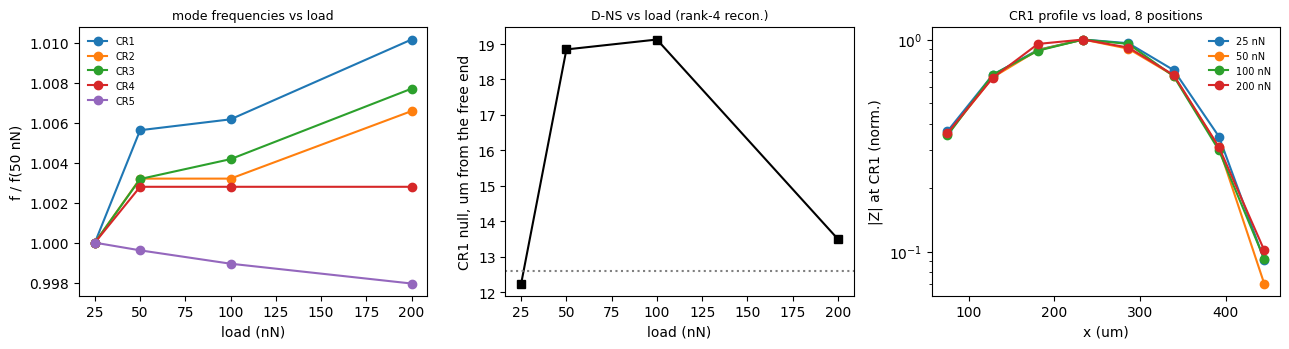

In [16]:
from activemodemap import reconstruct_series, load_checkpoint
if 'load_series' not in globals():
    load_series = load_checkpoint(LOAD_CHECKPOINT); conditions_L = load_series['conditions']
fL, xL = load_series['freq_Hz'], load_series['x_um']
def mode_peak_L(Zrow, f, fk_khz, half=None):
    half = half or MODE_HALF_WIN_HZ * max(1.0, fk_khz / 400.0) * 3      # loads move the peaks: wider windows
    w = np.abs(f - fk_khz * 1e3) <= half
    j = int(np.argmax(np.abs(Zrow[w]))); return Zrow[w][j], f[w][j]

print('load (nN) | f_CR1 .. f_CR5 (kHz), median over positions | CR1 Q (FWHM, antinode)')
rows = []
for i, c in enumerate(conditions_L):
    Zc = load_series['Z'][i]
    if not np.isfinite(Zc).all():
        ok = np.isfinite(Zc).all(axis=1); print(f'{c.load_nN:6.0f}   incomplete at x =', np.round(xL[~ok], 0)); Zc = Zc[ok]
    fpk = [np.median([mode_peak_L(z, fL, fk)[1] for z in Zc]) / 1e3 for fk in MODES_KHZ]
    # Q of CR1 from the antinode row
    w = np.abs(fL - fpk[0] * 1e3) <= 6e3; A = np.abs(Zc[:, w]); r = A[int(np.argmax(A.max(1)))]
    half = r >= r.max() / np.sqrt(2); Q = fpk[0] * 1e3 / (fL[w][half].max() - fL[w][half].min()) if half.sum() > 1 else np.nan
    rows.append((c.load_nN, fpk, Q)); print(f'{c.load_nN:6.0f}   ' + '  '.join(f'{v:7.2f}' for v in fpk) + f'   Q {Q:5.0f}')
rec = reconstruct_series(load_series, SPARSE_X_UM, rank=min(RANK, xL.size - 1), auto_band=True, band_halfwidth_Hz=20e3)
fig, axs = plt.subplots(1, 3, figsize=(13, 3.6))
L = [r[0] for r in rows]
for k in range(len(MODES_KHZ)):
    axs[0].plot(L, [r[1][k] / rows[0][1][k] for r in rows], 'o-', label=f'CR{k+1}')
axs[0].set_xlabel('load (nN)'); axs[0].set_ylabel('f / f(50 nN)'); axs[0].legend(fontsize=7, frameon=False); axs[0].set_title('mode frequencies vs load', fontsize=9)
axs[1].plot(L, [PROBE_L_UM - (r['dns_um'] if r else np.nan) for r in rec], 'ks-'); axs[1].axhline(12.6, color='grey', ls=':')
axs[1].set_xlabel('load (nN)'); axs[1].set_ylabel('CR1 null, um from the free end'); axs[1].set_title('D-NS vs load (rank-%d recon.)' % min(RANK, xL.size - 1), fontsize=9)
for i, c in enumerate(conditions_L):
    Zc = load_series['Z'][i]; fpk1 = rows[i][1][0] * 1e3; j = int(np.argmin(np.abs(fL - fpk1)))
    axs[2].semilogy(xL, np.abs(Zc[:, j]) / np.nanmax(np.abs(Zc[:, j])), 'o-', label=f'{c.load_nN:.0f} nN')
axs[2].set_xlabel('x (um)'); axs[2].set_ylabel('|Z| at CR1 (norm.)'); axs[2].legend(fontsize=7, frameon=False); axs[2].set_title('CR1 profile vs load, 8 positions', fontsize=9)
plt.tight_layout(); plt.savefig(os.path.join(file_loc, 'load_series_quicklook.png'), dpi=170); plt.show()


In [18]:
# Same scan path notebook 00 uses: DownScan_0 on the master panel, then poll
# root:packages:MFP3D:OutWaves until the scan stops outputting.
def _scanning(igor):
    return bool(igor.DataFolder(r'root:packages:MFP3D').Wave('OutWaves')
                .GetTextWavePointValue(0, 0))

def setup_imaging(automation, igor, size_m, points, rate_hz, f_drive, drive_V,
                  mode=None, tol=0.02):
    for k, v in (("ScanSize", size_m), ("ScanPoints", points), ("ScanLines", points),
                 ("ScanRate", rate_hz), ("DriveFrequency", f_drive),
                 ("DriveAmplitude", drive_V)):
        igor.Execute(f'PV("{k}", {v})')
    if mode:
        automation.ex('LastScanPopup_0', 'MasterPanel', 0, mode)
    time.sleep(1)

    gmv, bad = automation.get_gmv(), []
    for k, want in (("ScanSize", size_m), ("ScanPoints", points), ("ScanLines", points),
                    ("ScanRate", rate_hz), ("DriveFrequency", f_drive),
                    ("DriveAmplitude", drive_V)):
        if k not in gmv:
            print(f"  note: {k} not in MasterVariables - cannot verify"); continue
        got = gmv[k]
        ok = abs(got - want) <= tol * max(abs(want), 1e-12)
        print(f"  {k:<16} asked {want:<12.6g} reads {got:<12.6g} {'ok' if ok else '** MISMATCH'}")
        if not ok:
            bad.append(k)
    if bad:
        raise RuntimeError(f"panel did not take: {bad} - do not image on this")

    v_um_s = 2 * (size_m * 1e6) * rate_hz
    print(f"  tip velocity {v_um_s:.0f} um/s, {size_m*1e9/points:.0f} nm/pixel")
    return gmv
    
import glob

def setup_imaging(automation, igor, size_m, points, rate_hz, f_drive, drive_V,
                  mode=None, tol=0.02):
    for k, v in (("ScanSize", size_m), ("ScanPoints", points), ("ScanLines", points),
                 ("ScanRate", rate_hz), ("DriveFrequency", f_drive),
                 ("DriveAmplitude", drive_V)):
        igor.Execute(f'PV("{k}", {v})')
    if mode:
        automation.ex('LastScanPopup_0', 'MasterPanel', 0, mode)
    time.sleep(1)

    gmv, bad = automation.get_gmv(), []
    for k, want in (("ScanSize", size_m), ("ScanPoints", points), ("ScanLines", points),
                    ("ScanRate", rate_hz), ("DriveFrequency", f_drive),
                    ("DriveAmplitude", drive_V)):
        if k not in gmv:
            print(f"  note: {k} not in MasterVariables - cannot verify"); continue
        got = gmv[k]
        ok = abs(got - want) <= tol * max(abs(want), 1e-12)
        print(f"  {k:<16} asked {want:<12.6g} reads {got:<12.6g} {'ok' if ok else '** MISMATCH'}")
        if not ok:
            bad.append(k)
    if bad:
        raise RuntimeError(f"panel did not take: {bad} - do not image on this")

    v_um_s = 2 * (size_m * 1e6) * rate_hz
    print(f"  tip velocity {v_um_s:.0f} um/s, {size_m*1e9/points:.0f} nm/pixel")
    return gmv
def take_image(automation, base_filename, timeout_s=1800, settle_s=3):
    """Acquire one scan and return the file Igor ACTUALLY wrote.

    The old version predicted the name before the scan from a directory scan for
    {base}####.*. Igor's ARCheckSuffix() keeps its own counter, shared across base
    names: the FDomBias force curves had pushed it to 20, so the first DomBias
    image landed as DomBias0021.ibw while the Python side found no DomBias#### at
    all and predicted DomBias0000.ibw. Same root cause as the force-curve miss.
    """
    automation.set_folder()
    igor.Execute(f'root:Packages:MFP3D:Main:Variables:BaseName = "{base_filename}"')
    igor.Execute('PV("BaseSuffix", 0000)')
    igor.Execute('ARCheckSuffix()')

    pattern = os.path.join(automation.file_loc, f'{base_filename}*.ibw')
    before = {p: os.path.getmtime(p) for p in glob.glob(pattern)}
    t0 = time.time()

    automation.ex('DownScan_0', 'MasterPanel')
    time.sleep(10)
    while _scanning(igor) and time.time() - t0 < timeout_s:
        time.sleep(2)
    if time.time() - t0 >= timeout_s:
        print('  WARNING: scan did not finish within the timeout')
    time.sleep(settle_s)

    new = [p for p in glob.glob(pattern)
           if p not in before or os.path.getmtime(p) > before[p]]
    if not new:
        raise RuntimeError(f'scan finished but no new {base_filename}*.ibw appeared '
                           f'in {automation.file_loc} - did Igor save it?')
    path = max(new, key=os.path.getmtime)
    if len(new) > 1:
        print(f'  note: {len(new)} new files matched, taking the newest')

    last = -1                                  # wait for the write to finish
    for _ in range(20):
        size = os.path.getsize(path)
        if size == last and size > 0:
            break
        last = size
        time.sleep(0.5)
    else:
        print('  WARNING: file size still changing - may be partially written')

    print(f'  image: {os.path.basename(path)} ({os.path.getsize(path)/1e6:.2f} MB)')
    return path


img_path = take_image(inst.a, base_filename)
print('image saved:', img_path, os.path.exists(img_path))
inst.a.withdraw()
print('channels:', list_channels(img_path))

RuntimeError: scan finished but no new DomBias*.ibw appeared in D:\User Data\Liam\ActiveModeMap\DomainsBPPPCONTAU - did Igor save it?

## 5 · Find the two domains — then LOOK at the figure before running the next cell

`find_domain_spots` projects the wrapped phase onto the axis separating its two modes
(so any phase offset works), Otsu-thresholds it, median-filters out speckle, keeps the
largest connected component per orientation and takes the deepest interior point of
each. `margin_um` is the distance from that point to the nearest wall *or image edge*.

It raises rather than guessing when the two segments' mean phases are less than 60°
apart (a single-domain image split along its own noise) or when a spot sits within
0.5 µm of a wall.

In [ ]:
phase, meta = load_asylum_image(img_path, channel='Phase', trace='Trace')
print('using channel', meta['channel'], '| scan size %.1f um' % (meta['scan_size_m']*1e6))

spots = find_domain_spots(phase, meta['scan_size_m'])
for k, s in enumerate(spots, start=1):
    print(f"  candidate spot {k}: ({s['x_m']*1e6:6.2f}, {s['y_m']*1e6:6.2f}) um   "
          f"margin {s['margin_um']:.2f} um   area {s['area_frac']:.0%}   "
          f"mean phase {s['mean_phase_deg']:+.0f} deg")

fig = plot_domain_confirmation(phase, spots, meta['scan_size_m'],
                               save_path=os.path.join(file_loc, 'domain_spots.png'))
plt.show()

### Confirm

Both crosses inside their domains, both circles clear of any wall? If not, stop here and
mark the spots by hand with the Force-panel pick-spot instead — everything below works
the same either way, it only reads `SpotX`/`SpotY`.

In [ ]:
print('before:', [(f'{x*1e6:.2f}', f'{y*1e6:.2f}') for x, y in read_spots_from_igor(igor)])
numbers = write_spots_to_igor(igor, spots, start_index=1)
print('spot numbers written:', numbers)
print('after :', [(f'{x*1e6:.2f}', f'{y*1e6:.2f}') for x, y in read_spots_from_igor(igor)])

## 6 · Spot shakedown — the last chance to catch a wrong convention

Hops spot 1 → 2 → 1 with the tip **withdrawn**, reads the XY sensors at each, converts
the measured separation through `XLVDTSens`/`YLVDTSens` and compares it with the
separation the segmentation asked for. A ratio outside 0.8–1.25 means the spot
coordinates are not being interpreted the way this code assumes: **do not engage**.

`GoToSpot()` reads the geometry off the open image window, so leave the image from §4
open.

In [19]:
sep_m = float(np.hypot(spots[0]['x_m'] - spots[1]['x_m'],
                       spots[0]['y_m'] - spots[1]['y_m']))
ok, readings = verify_spot_moves(automation, numbers, expected_sep_m=sep_m)
print('\nshakedown OK:', ok)
assert ok, 'spot shakedown failed — see the message above; do not run the series'

NameError: name 'spots' is not defined

## 7 · The series — every bias at both domains, at each laser position

In [20]:
conditions = make_conditions(BIAS_V, LOAD_NN, spots=[SPOT_UP, SPOT_DOWN], bias_order=BIAS_ORDER)
print(f'{len(conditions)} conditions/position:', [str(c) for c in conditions])

# Fixed design, free end first (the laser is parked there after imaging). Position 1 only:
# the next cell is the go/no-go before the remaining seven.
SPARSE_ORDER = SPARSE_X_UM[::-1]
series = run_series(inst, SPARSE_X_UM, conditions, ref_index=REF_INDEX, rank=RANK,
                    dns_band_Hz=DNS_BAND_HZ, checkpoint_path=CHECKPOINT, resume=True,
                    positions_um=SPARSE_ORDER[:1], verbose=True)


14 conditions/position: ['+0.000 V, 15 nN, spot 1', '+9.000 V, 15 nN, spot 1', '-9.000 V, 15 nN, spot 1', '+6.000 V, 15 nN, spot 1', '-6.000 V, 15 nN, spot 1', '+3.000 V, 15 nN, spot 1', '-3.000 V, 15 nN, spot 1', '+0.000 V, 15 nN, spot 2', '+9.000 V, 15 nN, spot 2', '-9.000 V, 15 nN, spot 2', '+6.000 V, 15 nN, spot 2', '-6.000 V, 15 nN, spot 2', '+3.000 V, 15 nN, spot 2', '-3.000 V, 15 nN, spot 2']
fixed design: 1 positions, 445.0 -> 445.0 um; no convergence stop

=== position 1: x = 445.0 um (14 conditions) ===
      cal trigger 0.681 V (50 nN at InvOLS 4.95e-07 m/V)
      spot 1 reached after 3.2 s (XY = +0.1678, -0.3881 V)
      tune finished after 11.1 s
      cond 0: +0.00 V, 15 nN -> 47040 pts, f_res 63.86 kHz
      tune finished after 10.4 s
      cond 1: +9.00 V, 15 nN -> 47040 pts, f_res 64.07 kHz
      tune finished after 10.4 s
      cond 2: -9.00 V, 15 nN -> 47040 pts, f_res 64.08 kHz
      tune finished after 10.6 s
      cond 3: +6.00 V, 15 nN -> 47040 pts, f_res 64.27 k

### Go / no-go after position 1

Prediction from the wideband ladder (`pppcontau-electrostatic-vs-contact-drive-2026-09-18`):
electrostatic/piezo ≈ 4 at CR1, ≈ 0.6 at CR2, ≈ 0.06 at CR5. So **CR1 swings hard with bias and
CR3–CR5 barely**, and at 0 V **CR3–CR5 flip ~180° between domains while CR1 flips much less**.
If CR3 swings like CR1, or all modes flip identically, the mixture picture is wrong — stop here.

x = 445 um
mode      swing(up)  swing(down)   0 V domain flip
   63.5      4.54       8.58         30 deg
  200.1      3.10       4.55        173 deg
  408.0      1.01       1.94        119 deg
  667.3      0.66       1.16        143 deg
  916.1      0.49       0.86        162 deg


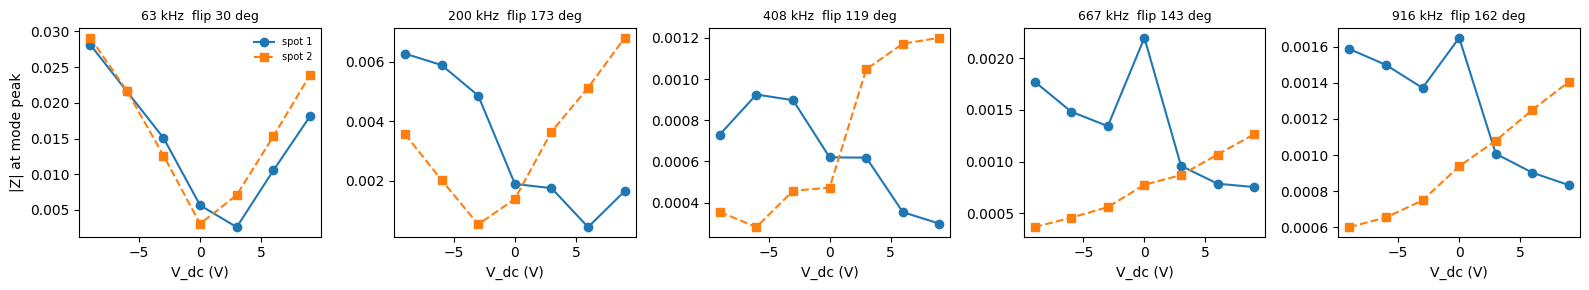

GO if: CR1 swing >> CR3-CR5 swing, and CR3-CR5 flip ~180 deg while CR1 flips much less.


In [21]:
def mode_peak(Zrow, f, fk_khz, half=MODE_HALF_WIN_HZ):
    w = np.abs(f - fk_khz * 1e3) <= half
    j = int(np.argmax(np.abs(Zrow[w]))); return Zrow[w][j], f[w][j]

def bias_table(series, conditions, x_index=-1):
    """Per mode and spot: |Z| at the mode peak vs bias, its swing, and the 0 V domain flip."""
    f = series['freq_Hz']; out = {}
    for fk in MODES_KHZ:
        row = {}
        for spot in (SPOT_UP, SPOT_DOWN):
            V, A, Z0 = [], [], None
            for i, c in enumerate(conditions):
                if c.spot != spot: continue
                z, _ = mode_peak(series['Z'][i, x_index], f, fk)
                V.append(c.bias_V); A.append(abs(z))
                if abs(c.bias_V) < 1e-9: Z0 = z
            V, A = np.array(V), np.array(A); o = np.argsort(V)
            row[spot] = dict(V=V[o], A=A[o], swing=(A.max() - A.min()) / A[np.argmin(np.abs(V))], Z0=Z0)
        flip = np.degrees(np.angle(row[SPOT_UP]['Z0'] * np.conj(row[SPOT_DOWN]['Z0'])))
        out[fk] = dict(row, flip_deg=flip)
    return out

tab = bias_table(series, conditions)
print(f"x = {series['x_um'][-1]:.0f} um")
print('mode      swing(up)  swing(down)   0 V domain flip')
for fk, r in tab.items():
    print(f'{fk:7.1f}  {r[SPOT_UP]["swing"]:8.2f}  {r[SPOT_DOWN]["swing"]:9.2f}     {abs(r["flip_deg"]):6.0f} deg')
fig, axs = plt.subplots(1, len(MODES_KHZ), figsize=(3.2 * len(MODES_KHZ), 3), sharey=False)
for ax, (fk, r) in zip(axs, tab.items()):
    for spot, st in ((SPOT_UP, 'o-'), (SPOT_DOWN, 's--')):
        ax.plot(r[spot]['V'], r[spot]['A'], st, label=f'spot {spot}')
    ax.set_title(f'{fk:.0f} kHz  flip {abs(r["flip_deg"]):.0f} deg', fontsize=9); ax.set_xlabel('V_dc (V)')
axs[0].set_ylabel('|Z| at mode peak'); axs[0].legend(fontsize=7, frameon=False)
plt.tight_layout(); plt.savefig(os.path.join(file_loc, 'position1_go_nogo.png'), dpi=160); plt.show()
print('GO if: CR1 swing >> CR3-CR5 swing, and CR3-CR5 flip ~180 deg while CR1 flips much less.')


### Remaining seven sparse positions (resumes from the checkpoint; position 1 is not repeated)

In [ ]:
series = run_series(inst, SPARSE_X_UM, conditions, ref_index=REF_INDEX, rank=RANK,
                    dns_band_Hz=DNS_BAND_HZ, checkpoint_path=CHECKPOINT, resume=True,
                    positions_um=SPARSE_ORDER, verbose=True)
print(f"\n{series['x_um'].size} positions x {len(conditions)} conditions x {series['freq_Hz'].size} frequencies")


resumed from D:\User Data\Liam\ActiveModeMap\DomainsBPPPCONTAU\domains_bias_checkpoint.npz: 1 positions already measured
fixed design: 8 positions, 445.0 -> 75.0 um; no convergence stop

=== position 2: x = 392.1 um (14 conditions) ===
      cal trigger 0.694 V (50 nN at InvOLS 4.87e-07 m/V)
      spot 1 reached after 3.2 s (XY = +0.1678, -0.3881 V)
      tune finished after 10.5 s
      cond 0: +0.00 V, 15 nN -> 47040 pts, f_res 63.99 kHz


## 7b · Free-end cluster — does the CR1 null move with bias?

420–445 µm at 2 µm pitch, one domain, 5 biases, interleaved. Its own checkpoint. Add
`SPOT_DOWN` to `CLUSTER_SPOTS` for the two-domain version if time allows.

In [ ]:
conditions_c = make_conditions(CLUSTER_BIAS_V, LOAD_NN, spots=CLUSTER_SPOTS, bias_order=BIAS_ORDER)
print(f'{len(conditions_c)} conditions/position:', [str(c) for c in conditions_c])
cluster = run_series(inst, CLUSTER_X_UM, conditions_c, ref_index=0, rank=2,
                     dns_band_Hz=DNS_BAND_HZ, checkpoint_path=CLUSTER_CHECKPOINT, resume=True,
                     positions_um=CLUSTER_X_UM[::-1], verbose=True)
inst.close()
print(f"\ncluster: {cluster['x_um'].size} positions x {len(conditions_c)} conditions")


## 8 · Separate the channels

Two independent routes to the same split, which is the point of taking nine biases:

* **domain difference** at each bias — exact, no fit;
* **complex bias fit** `Z = a + bV` — slope is pure electrostatic with no `V_cpd` term.

If the D-ESBS from the two disagrees by more than the CI, suspect a contact-gain
difference between the spots rather than physics.

In [ ]:
# route 1 -- domain difference at 0 V (exact, no fit)
ch_dom = separate_domains(series, spot_up=SPOT_UP, spot_down=SPOT_DOWN,
                          bias_V=0.0, load_nN=LOAD_NN[0])
sp_dom = channel_spots(ch_dom, SPARSE_X_UM, rank=min(RANK, len(series['x_um']) - 1), band_Hz=DNS_BAND_HZ)

# route 2 -- complex bias fit Z = a + bV over all nine biases, on the UP domain
series_up = dict(series)
keep = [i for i, c in enumerate(series['conditions']) if c.spot == SPOT_UP]
series_up['conditions'] = [series['conditions'][i] for i in keep]
series_up['Z'] = series['Z'][keep]
# v_cpd = 0 leaves a -V_cpd*b electrostatic term in the "piezo" channel (SCM-PIT lesson:
# with V_cpd = -1.9 V that term was 97-108 % of the channel). Estimate, then re-separate.
ch_0 = separate_channels(series_up, load_nN=LOAD_NN[0], v_cpd=0.0)
vc_pos, V_CPD = estimate_v_cpd(ch_0, band_Hz=DNS_BAND_HZ)       # (per position, median)
print(f'\nV_cpd proxy (CR1 band, median over positions): {V_CPD:+.3f} V; per position', np.round(vc_pos, 2))
print('   proxy is exact only where the piezoresponse vanishes; the two-domain split below gives the real V_cpd')
ch_fit = separate_channels(series_up, load_nN=LOAD_NN[0], v_cpd=V_CPD)
sp_fit = channel_spots(ch_fit, SPARSE_X_UM, rank=min(RANK, len(series['x_um']) - 1), band_Hz=DNS_BAND_HZ)

for name, sp_ in (('domain difference', sp_dom), ('bias fit', sp_fit)):
    print(f"{name:>18}:  D-NS {PROBE_L_UM - sp_['dns']['value_um']:6.2f} um   "
          f"D-ESBS {PROBE_L_UM - sp_['desbs']['value_um']:6.2f} um  (from the free end)")
print("dense-sweep reference 2026-09-17: displacement null 12.5 um from the tip")

In [ ]:
# Bias dependence per domain at each mode's OWN peak (not a fixed bin: the peak moves a
# few hundred Hz with bias and a fixed bin turns that into fake non-linearity).
fig, axs = plt.subplots(1, len(MODES_KHZ), figsize=(3.2 * len(MODES_KHZ), 3))
for ax, fk in zip(axs, MODES_KHZ):
    for spot, style in ((SPOT_UP, 'o-'), (SPOT_DOWN, 's--')):
        V, A = [], []
        for i, c in enumerate(conditions):
            if c.spot != spot: continue
            A.append(np.mean([abs(mode_peak(series['Z'][i, j], series['freq_Hz'], fk)[0])
                              for j in range(series['x_um'].size)])); V.append(c.bias_V)
        o = np.argsort(V); ax.plot(np.array(V)[o], np.array(A)[o], style, label=f'spot {spot}')
    ax.set_title(f'{fk:.0f} kHz', fontsize=9); ax.set_xlabel('DC bias (V)')
axs[0].set_ylabel('|Z| at mode peak, mean over positions'); axs[0].legend(frameon=False, fontsize=7)
plt.tight_layout(); plt.savefig(os.path.join(file_loc, 'bias_dependence_per_mode.png'), dpi=180); plt.show()


### Electrostatic / piezo ratio per mode

Piezo term flips with domain and is bias-independent: P = (Z_up − Z_down)/2 at each V.
Electrostatic term is domain-independent and linear in V: E(V) = (Z_up + Z_down)/2 = S·(V − V_cpd).
Fit S and V_cpd from E(V); the ratio that matters for interpretation is |S·V_cpd| / |P| — the
electrostatic share of the 0 V signal. Prediction: ≈ 4 at CR1, ≈ 0.6 at CR2, ≲ 0.1 at CR4–CR5.

In [ ]:
def two_domain_split(series, conditions, fk):
    """Per position: P (piezo, bias-averaged), S, V_cpd, and the 0 V electrostatic/piezo ratio."""
    f = series['freq_Hz']; rows = []
    for j in range(series['x_um'].size):
        zu = {c.bias_V: mode_peak(series['Z'][i, j], f, fk)[0] for i, c in enumerate(conditions) if c.spot == SPOT_UP}
        zd = {c.bias_V: mode_peak(series['Z'][i, j], f, fk)[0] for i, c in enumerate(conditions) if c.spot == SPOT_DOWN}
        V = np.array(sorted(set(zu) & set(zd)))
        P = np.array([(zu[v] - zd[v]) / 2 for v in V]); E = np.array([(zu[v] + zd[v]) / 2 for v in V])
        A = np.c_[V, np.ones_like(V)]; (S, c0), *_ = np.linalg.lstsq(A, E, rcond=None)
        v_cpd = -np.real(c0 / S) if abs(S) > 0 else np.nan
        Pm = P.mean(); resid = np.linalg.norm(E - (S * V + c0)) / np.linalg.norm(E)
        rows.append(dict(x=series['x_um'][j], P=abs(Pm), P_scatter=np.std(np.abs(P)) / abs(Pm),
                         S=abs(S), v_cpd=v_cpd, ratio0=abs(S * v_cpd) / abs(Pm), lin_resid=resid))
    return rows

print('mode    <ratio0>   V_cpd (mean +/- sd)   P scatter over V   E(V) linearity resid')
summary = {}
for fk in MODES_KHZ:
    r = two_domain_split(series, conditions, fk)
    ratio = np.array([q['ratio0'] for q in r]); vc = np.array([q['v_cpd'] for q in r])
    summary[fk] = dict(ratio0=np.median(ratio), v_cpd=np.nanmean(vc), rows=r)
    print(f'{fk:7.1f}  {np.median(ratio):8.2f}   {np.nanmean(vc):+6.2f} +/- {np.nanstd(vc):4.2f}     '
          f'{np.mean([q["P_scatter"] for q in r]):.2f}              {np.mean([q["lin_resid"] for q in r]):.2f}')
print('prediction from the wideband ladder: ratio0 ~ 4 (CR1), ~0.6 (CR2), <0.1 (CR4-CR5); V_cpd should be the same for every mode')


### CR1 null locus vs bias (free-end cluster)

Two-pathway model, ε ≈ 4 at CR1: **on resonance** the null stays at the mode-shape node
(12.6 µm from the tip; drive-independent — if it moves, the axis or the contact moved).
**Off resonance** the null is where piezo and electrostatic contributions cancel, so its
position depends on V_dc − V_cpd: the model predicts shifts of 5–30 µm at ±3 kHz from the
peak between −4 and +4 V, collapsing to zero as V_dc → V_cpd on one side. That locus vs
frequency, per bias, is the electrostatic signature; contact drive alone gives a locus that
does not depend on bias.

In [ ]:
fc = cluster['freq_Hz']; xc = cluster['x_um']
def null_position(Zmap_x, x):
    """Parabolic minimum of log|Z| along x."""
    a = np.log(np.abs(Zmap_x) + 1e-15); i = int(np.argmin(a))
    if 0 < i < len(a) - 1:
        y0, y1, y2 = a[i - 1], a[i], a[i + 1]; den = y0 - 2 * y1 + y2
        return x[i] + (x[1] - x[0]) * 0.5 * (y0 - y2) / den if den != 0 else x[i]
    return x[i]

# CR1 peak frequency from the 0 V spectra (mean over the cluster)
i0 = [i for i, c in enumerate(conditions_c) if abs(c.bias_V) < 1e-9][0]
w1 = np.abs(fc - MODES_KHZ[0] * 1e3) <= MODE_HALF_WIN_HZ
f_pk = fc[w1][int(np.argmax(np.abs(cluster['Z'][i0][:, w1]).mean(0)))]
OFFSETS_HZ = [-3e3, -1e3, 0.0, 1e3, 3e3]

fig, axs = plt.subplots(1, len(conditions_c) + 1, figsize=(3.0 * (len(conditions_c) + 1), 3.6))
order = np.argsort([c.bias_V for c in conditions_c])
table = {}
for ax, i in zip(axs, order):
    c = conditions_c[i]; Zc = cluster['Z'][i]                      # (n_pos, n_freq)
    wb = np.abs(fc - f_pk) <= 8e3
    ax.pcolormesh(fc[wb] / 1e3, xc, 20 * np.log10(np.abs(Zc[:, wb]) + 1e-15), cmap='magma', shading='auto')
    ax.set_title(f'{c.bias_V:+.0f} V', fontsize=9); ax.set_xlabel('f (kHz)')
    row = []
    for off in OFFSETS_HZ:
        j = int(np.argmin(np.abs(fc - (f_pk + off)))); xn = null_position(Zc[:, j], xc); row.append(PROBE_L_UM - xn)
        ax.plot(fc[j] / 1e3, xn, 'c+', ms=8)
    table[c.bias_V] = row
axs[0].set_ylabel('x (um)')
ax = axs[-1]
for k, off in enumerate(OFFSETS_HZ):
    ax.plot(sorted(table), [table[v][k] for v in sorted(table)], 'o-', label=f'{off/1e3:+.0f} kHz')
ax.axhline(12.6, color='grey', ls=':'); ax.set_xlabel('DC bias (V)'); ax.set_ylabel('null, um from free end')
ax.legend(fontsize=7, frameon=False, title='f - f_CR1'); ax.set_title('null locus vs bias', fontsize=9)
plt.tight_layout(); plt.savefig(os.path.join(file_loc, 'cr1_null_locus_vs_bias.png'), dpi=180); plt.show()
print(f'CR1 peak {f_pk/1e3:.2f} kHz.  null position (um from the free end) at f - f_CR1 =', [f'{o/1e3:+.0f}' for o in OFFSETS_HZ], 'kHz')
for v in sorted(table): print(f'  {v:+.0f} V:', np.round(table[v], 1))
print('expect: the 0 kHz column constant (mode-shape node); the +/-1, +/-3 kHz columns moving with bias if electrostatics dominate CR1')
